# HIF Dataset Preparation

In [14]:
import xgi
from hydra.core.data.utils import hypergraph_laplacian_zhou
from scipy.sparse.linalg import eigsh
from gdown import download
import tarfile
from os import remove, makedirs
from shutil import rmtree

In [15]:
gdrive_id = "1amLeVudLBDRglCXKlieg6HHE-vu81EVF"

In [16]:
file_name = download(id=gdrive_id)

Downloading...
From: https://drive.google.com/uc?id=1amLeVudLBDRglCXKlieg6HHE-vu81EVF
To: /home/valerio/Documents/hydra/examples/email-Eu.tar.gz
100%|██████████| 1.36M/1.36M [00:00<00:00, 7.91MB/s]


In [17]:
dataset_name = file_name.split(".")[0]
dataset_path = f"datasets"

In [18]:
with tarfile.open(file_name) as tar:
    tar.extractall(path=dataset_path)
remove(file_name)

/tmp/ipykernel_8494/913762149.py:2: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(path=dataset_path)


In [19]:
hyperedges = []
with open(f"{dataset_path}/{dataset_name}/{dataset_name}-nverts.txt") as f:
    with open(f"{dataset_path}/{dataset_name}/{dataset_name}-simplices.txt") as g:
        for nvert_line in f:
            nvert = int(nvert_line)
            # Read as many lines as nvert from g
            verts = []
            for _ in range(nvert):
                simplex_line = g.readline()
                simplex = int(simplex_line)
                verts.append(simplex)
            hyperedges.append(sorted(verts))
hyperedges = list(set(map(tuple, hyperedges)))
hypergraph = xgi.Hypergraph(hyperedges)

vertices_idx = sorted(hypergraph.nodes)
if vertices_idx != list(range(len(vertices_idx))):
    hyperedges = [[vertices_idx.index(v) for v in he] for he in hyperedges]
    hyperedges = list(set(map(tuple, hyperedges)))
hypergraph = xgi.Hypergraph(hyperedges)

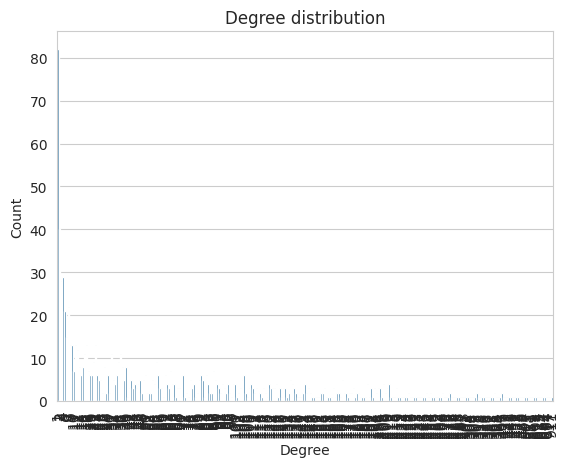

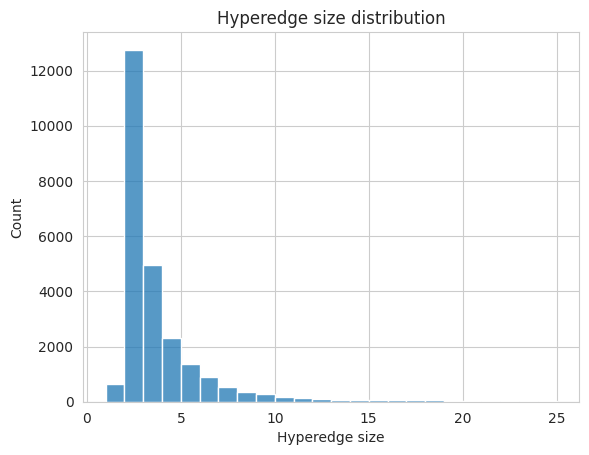

array([    0,   628, 12753,  4938,  2294,  1359,   888,   551,   352,
         272,   188,   134,   112,    75,    72,    66,    54,    46,
          52,    43,    37,    32,    29,    18,    15,    19])

In [26]:
bin, count = xgi.degree_histogram(hypergraph)
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style("whitegrid")

sns.barplot(x=bin, y=count)
plt.xlabel("Degree")
plt.ylabel("Count")
plt.xticks(rotation=90)
plt.title("Degree distribution")
plt.show()

# Plot hyperedge sizes
hyperedge_sizes = [len(he) for he in hypergraph.edges.members()]
sns.histplot(hyperedge_sizes, bins=range(1, max(hyperedge_sizes) + 1))
plt.xlabel("Hyperedge size")
plt.ylabel("Count")
plt.title("Hyperedge size distribution")
plt.show()

import numpy as np
np.bincount(hyperedge_sizes)

In [21]:
len(list(xgi.connected_components(hypergraph)))

20

In [22]:
len(xgi.largest_connected_component(hypergraph)) / len(hypergraph.nodes)

0.9809619238476954

### eigsh

In [ ]:
incidence_matrix, coldict, rowdict = xgi.incidence.incidence_matrix(hypergraph, index=True)
Delta = hypergraph_laplacian_zhou(incidence_matrix)
_, X = eigsh(Delta, k=128, which="SM")  # smallest magnitude eigenvalues
Delta = hypergraph_laplacian_zhou(incidence_matrix.T)
_, Y = eigsh(Delta, k=128, which="SM")  # smallest magnitude eigenvalues
rowlist = [value for value in rowdict.values()]
collist = [value for value in coldict.values()]

In [ ]:
for node in hypergraph.nodes:
    node_idx = collist.index(node)
    hypergraph.set_node_attributes({
        node: {"eigsh": X[node_idx].tolist()},
    })
for edge in hypergraph.edges:
    edge_idx = rowlist.index(edge)
    hypergraph.set_edge_attributes({
        edge: {"eigsh": Y[edge_idx].tolist()},
    })

### node2vec

In [ ]:
import torch
from torch_geometric.utils import from_networkx, add_remaining_self_loops
from torch_geometric.nn import Node2Vec
from tqdm import tqdm

def node2vec_embeddings_pyg(G, embedding_dim=128, walk_length=20, context_size=10,
                           walks_per_node=10, num_negative_samples=1, p=1.0, q=1.0,
                           lr=0.01, epochs=100, device=None, batch_size=128):
    data = from_networkx(G)
    edge_index = data.edge_index

    if device is None:
        device = "cuda" if torch.cuda.is_available() else "cpu"

    num_nodes = data.num_nodes

    edge_index, _ = add_remaining_self_loops(edge_index, num_nodes=num_nodes)

    model = Node2Vec(
        edge_index=edge_index,
        num_nodes=num_nodes,
        embedding_dim=embedding_dim,
        walk_length=walk_length,
        context_size=context_size,
        walks_per_node=walks_per_node,
        num_negative_samples=num_negative_samples,
        p=p,
        q=q,
        sparse=True,
    ).to(device)

    optimizer = torch.optim.SparseAdam(list(model.parameters()), lr=lr)

    loader = model.loader(batch_size=batch_size, shuffle=True, num_workers=0)

    model.train()
    total_loss = 0
    for _ in tqdm(range(epochs), desc="Training Node2Vec"):
        total_loss = 0
        for pos_rw, neg_rw in loader:
            pos_rw, neg_rw = pos_rw.to(device), neg_rw.to(device)
            optimizer.zero_grad()
            loss = model.loss(pos_rw, neg_rw)
            loss.backward()
            optimizer.step()
            total_loss += float(loss)
    print(f"Final loss: {total_loss:.4f}")

    # Get embedding matrix [num_nodes, embedding_dim]
    model.eval()
    Z = model().detach().cpu()

    # Map back to your NetworkX node IDs (PyG uses 0..N-1 ordering from conversion)
    nodes = list(G.nodes())
    embeddings = {nodes[i]: Z[i].numpy() for i in range(len(nodes))}
    return embeddings

In [ ]:
G = xgi.convert.to_graph(hypergraph)
n2v_X = node2vec_embeddings_pyg(
    G, p=2.0, q=0.5, epochs=500, batch_size=1024,
)
LG = xgi.convert.to_line_graph(hypergraph)
n2v_Y = node2vec_embeddings_pyg(
    LG, p=2.0, q=0.5, epochs=500, batch_size=1024,
)

Training Node2Vec: 100%|██████████| 500/500 [00:02<00:00, 216.14it/s]


Final loss: 2.1013


Training Node2Vec: 100%|██████████| 500/500 [00:49<00:00, 10.16it/s]

Final loss: 2.3784


In [ ]:
for node in hypergraph.nodes:
    hypergraph.set_node_attributes({
        node: {"n2v": n2v_X[node].tolist()},
    })
for edge in hypergraph.edges:
    hypergraph.set_edge_attributes({
        edge: {"n2v": n2v_Y[edge].tolist()},
    })

### villain

In [ ]:
import scipy.sparse as sp
import pickle as pkl

# Get incidence matrix coordinate format
coo = sp.coo_matrix(incidence_matrix)
makedirs(f"data/{dataset_name}", exist_ok=True)
with open(f"data/{dataset_name}/H.pickle", "wb") as f:
    pkl.dump([
        torch.tensor(coo.row),
        torch.tensor(coo.col),
    ], f)
makedirs(f"data/{dataset_name}_T", exist_ok=True)
with open(f"data/{dataset_name}_T/H.pickle", "wb") as f:
    pkl.dump([
        torch.tensor(coo.col),
        torch.tensor(coo.row),
    ], f)

In [ ]:
gpu=0
data=dataset_name

dim=128
lr=0.01

num_step=4
num_step_gen=10

for nl in [2, 3, 4, 5, 6, 7, 8]:
    !python VilLain/code/main.py --gpu $gpu --dataset $data --num_step $num_step --num_step_gen $num_step_gen --lr $lr --num_labels $nl --dim $dim
!python VilLain/code/emb_concat.py --dataset $data --num_step $num_step --num_step_gen $num_step_gen
for nl in [2, 3, 4, 5, 6, 7, 8]:
    remove(f"embs/{dataset_name}_dim{dim}_nl{nl}_ns{num_step}_nsg{num_step_gen}.pkl")

data = dataset_name + "_T"

for nl in [2, 3, 4, 5, 6, 7, 8]:
    !python VilLain/code/main.py --gpu $gpu --dataset $data --num_step $num_step --num_step_gen $num_step_gen --lr $lr --num_labels $nl --dim $dim
!python VilLain/code/emb_concat.py --dataset $data --num_step $num_step --num_step_gen $num_step_gen
for nl in [2, 3, 4, 5, 6, 7, 8]:
    remove(f"embs/{dataset_name}_T_dim{dim}_nl{nl}_ns{num_step}_nsg{num_step_gen}.pkl")

Device:	 cuda:0 

V = 143	E = 1512
Sparsity = 0.021043771877884865
10	5.3833394050598145	-0.24149757623672485
20	5.382113456726074	-0.2328222393989563
30	5.3793816566467285	-0.2408199906349182
40	5.378861904144287	-0.24122405052185059
50	5.373197555541992	-0.26084303855895996
60	5.350455284118652	-0.2913811206817627
70	5.328749179840088	-0.33274734020233154
80	5.280035018920898	-0.39976590871810913
90	5.2461442947387695	-0.44201624393463135
100	5.192846298217773	-0.5131344199180603
110	5.09254789352417	-0.6459534168243408
120	4.996817111968994	-0.763789713382721
130	4.885097980499268	-0.8724995255470276
140	4.7932891845703125	-0.9767533540725708
150	4.687618255615234	-1.0722558498382568
160	4.560916900634766	-1.1871726512908936
170	4.452099323272705	-1.26198148727417
180	4.301584243774414	-1.382847785949707
190	4.223583221435547	-1.4273159503936768
200	4.128405570983887	-1.495452642440796
210	4.034554481506348	-1.5521937608718872
220	3.9502034187316895	-1.5899814367294312
230	3.8758354

In [ ]:
with open(f"embs/{dataset_name}_dim{dim}_ns{num_step}_nsg{num_step_gen}_merged.pkl", "rb") as f:
    embs = pkl.load(f).tolist()
with open(f"embs/{dataset_name}_T_dim{dim}_ns{num_step}_nsg{num_step_gen}_merged.pkl", "rb") as f:
    embs_T = pkl.load(f).tolist()

In [ ]:
for node in hypergraph.nodes:
    node_idx = collist.index(node)
    hypergraph.set_node_attributes({
        node: {"villain": X[node_idx].tolist()},
    })
for edge in hypergraph.edges:
    edge_idx = rowlist.index(edge)
    hypergraph.set_edge_attributes({
        edge: {"villain": Y[edge_idx].tolist()},
    })

In [ ]:
import json
rmtree(f"{dataset_path}/{dataset_name}")

hif = dict(xgi.to_hif_dict(hypergraph))

makedirs(f"{dataset_path}/{dataset_name}/data", exist_ok=True)
with open(f"{dataset_path}/{dataset_name}/data/full-00000-of-00001.json", "w") as f:
    json.dump(hif, f)

In [ ]:
remove(f"embs/{dataset_name}_dim{dim}_ns{num_step}_nsg{num_step_gen}_merged.pkl")
remove(f"embs/{dataset_name}_T_dim{dim}_ns{num_step}_nsg{num_step_gen}_merged.pkl")